In [1]:
# ALL important import statements & reading in data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
import gdown

# 1. Determine the url to import
file_id = '1Xe-t8WmpzgYAIoax3H624TvN2QUX2YrB'
url = f'https://drive.google.com/uc?id={file_id}'

# 2. Download the file locally
output_file = 'downloaded_model.pkl'
gdown.download(url, output_file, quiet=False)

# 3. Load the downloaded pickle file
with open(output_file, 'rb') as file:
    tag_dict = pickle.load(file)

Downloading...
From: https://drive.google.com/uc?id=1Xe-t8WmpzgYAIoax3H624TvN2QUX2YrB
To: /home/bbothello/private/Group-SP26-089/downloaded_model.pkl
100%|██████████| 5.25M/5.25M [00:00<00:00, 27.4MB/s]


In [3]:
#Test call
print(tag_dict['FPS']['2026_Ratings'])

0     voted_up
False    8
True     8
Name: count, dt...
1     voted_up
True     7
False    5
Name: count, dt...
2     voted_up
False    246
True      69
Name: count...
3     voted_up
False    337
True     207
Name: count...
4     voted_up
True     6725
False     408
Name: cou...
                            ...                        
85                                                  NaN
86    voted_up
True     991
False    240
Name: count...
87    voted_up
True     383
False    116
Name: count...
88    voted_up
True     912
False     76
Name: count...
89    voted_up
True     3
False    2
Name: count, dt...
Name: 2026_Ratings, Length: 90, dtype: object


In [4]:
#Function to get the percentages per year for a tag
def GetPercentages(tag):
    #Initialize the year vars
    two_four = np.NaN
    two_five = np.NaN
    two_six = np.NaN

    #See if we can get the actual percentages for each year for the tag
    two_four = GetPercentForYear(tag['2024_Ratings'])
    two_five = GetPercentForYear(tag['2025_Ratings'])
    two_six = GetPercentForYear(tag['2026_Ratings'])
    return two_four, two_five, two_six

def GetPercentForYear(col):
    #Initialize vars
    total_percent_sum = 0
    num_reviews_added = 0
    series_index = 0
    #Add the percentage for each game in the tag
    for game in col:
        #Conditional to ignore if the game doesn't have reviews for this year (would be np.NaN)
        if type(col[series_index]) is pd.Series:

            #Get the number of positive reviews for the game that year
            if True in col[series_index].index:
                num_pos = col[series_index].loc[True]
            else:
                num_pos = 0

            #Get the number of negatibe reviews for the game that year
            if False in col[series_index].index:
                num_neg = col[series_index].loc[False]
            else:
                num_neg = 0
            
            #Calculate the decimal percentage for this game this year
            if (num_pos != 0) or (num_neg != 0):         
                total_percent_sum += (num_pos / (num_pos + num_neg))
                num_reviews_added += 1
        series_index += 1
    #If there is at least one review percentage for this tag, calculate the average percent for this year
    if num_reviews_added != 0:
        return (total_percent_sum / num_reviews_added)
    else:
        return np.NaN

In [5]:
#Test this function using the FPS tag
two_four, two_five, two_six = GetPercentages(tag_dict["FPS"])

print("2024: " + str(two_four))
print("2025: " + str(two_five))
print("2026: " + str(two_six))


2024: 0.7544946500845711
2025: 0.7574464245603989
2026: 0.7545698501805493


   Tag  Year    Rating
0  FPS  2024  0.754495
1  FPS  2025  0.757446
2  FPS  2026  0.754570


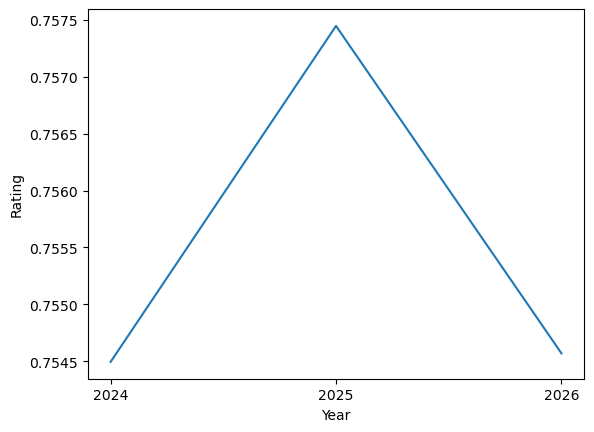

In [6]:
#Verify that tags would be combined in a line graph
data = [
    ['FPS', '2024', two_four],
    ['FPS', '2025', two_five],
    ['FPS', '2026', two_six]
]

cols = ['Tag', 'Year', 'Rating']

df = pd.DataFrame(data, columns=cols)
print(df)
f1 = sns.lineplot(df, x = 'Year', y = 'Rating')

In [7]:
#Create a dataframe for the tags and their yearly percent averages
cols = ['Tag', 'Year', 'Rating']
df = pd.DataFrame(columns=cols)

#List the top ten tags to analyze
top_ten = ['Indie', 'Action', 'Adventure', 'Casual', 'Singleplayer', 'Simulation', 'RPG', 'RPG', '2D', '3D']

#Add each average percentage for each tag per year
for tag in top_ten:
    two_four, two_five, two_six = GetPercentages(tag_dict[tag])
    df.loc[len(df)] = [tag, '2024', two_four]
    df.loc[len(df)] = [tag, '2025', two_five]
    df.loc[len(df)] = [tag, '2026', two_six]

#Verify data
print(df.head())

      Tag  Year    Rating
0   Indie  2024  0.893223
1   Indie  2025  0.888226
2   Indie  2026  0.860022
3  Action  2024  0.783338
4  Action  2025  0.795346


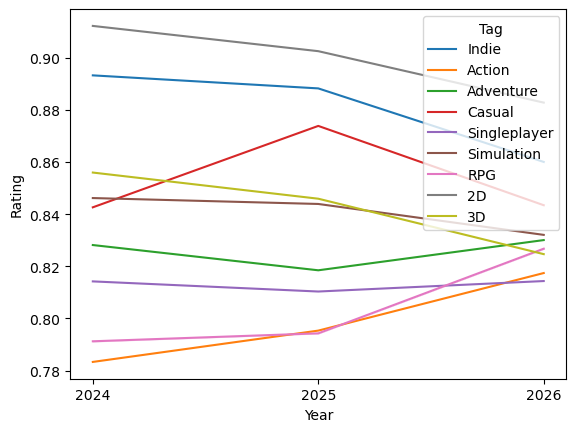

In [8]:
f1 = sns.lineplot(df, x = 'Year', y = 'Rating', hue = 'Tag')